# Gemma-2-2B Tour

Same walk as 01 on GPT-2, now on the 2B model: does TransformerLens compute what HuggingFace computes, what does the architecture look like from inside, how do residual norms grow, are the induction heads there, and how does the chat twin behave.


In [1]:
# HuggingFace first: load gemma-2-2b, keep its last-token logits as the reference, free it. Then
# TransformerLens loads from disk as in the smoke test (handing it the loaded HF model runs TL's
# float32 weight processing on MPS and exceeds the memory limit). Expectation: logits agree within
# bf16 noise (max |diff| < 0.4 on a scale of 20-30, top-1 identical); TL skips centre_unembed itself.
import gc
import time
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer

MODEL = "google/gemma-2-2b"
DEVICE = "mps"
PROMPT = "The capital of France is Paris. Interpretability researchers"

def mps_gb():
    return torch.mps.current_allocated_memory() / 1e9

t0 = time.time()
hf_model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.bfloat16).to(DEVICE).eval()
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokens = hf_tokenizer(PROMPT, return_tensors="pt").input_ids.to(DEVICE)
with torch.no_grad():
    hf_logits = hf_model(tokens).logits[0, -1].float()
print(f"HF loaded + forward in {time.time() - t0:.0f} s, {mps_gb():.1f} GB on MPS, {tokens.shape[1]} tokens")
del hf_model
gc.collect()
torch.mps.empty_cache()

t0 = time.time()
model = HookedTransformer.from_pretrained(MODEL, device=DEVICE, dtype=torch.bfloat16)
print(f"TL loaded in {time.time() - t0:.0f} s, {mps_gb():.1f} GB on MPS")

with torch.no_grad():
    tl_logits = model(tokens)[0, -1].float()
diff = (tl_logits - hf_logits).abs()
print(f"max |TL - HF| {diff.max():.3f}   mean {diff.mean():.4f}   logit scale {hf_logits.abs().max():.1f}")
print(f"top-1 HF {hf_tokenizer.decode(hf_logits.argmax().item())!r}   TL {model.tokenizer.decode(tl_logits.argmax().item())!r}")
print(f"same tokens from TL's tokenizer: {torch.equal(model.to_tokens(PROMPT), tokens)}")

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

HF loaded + forward in 10 s, 5.2 GB on MPS, 11 tokens


/Users/Brose/dev/private_repos/mechinterp_xai/.venv/lib/python3.13/site-packages/transformer_lens/config/hooked_transformer_config.py:354: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.13.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
TL loaded in 128 s, 6.5 GB on MPS
max |TL - HF| 0.375   mean 0.0550   logit scale 28.6
top-1 HF ' have'   TL ' have'
same tokens from TL's tokenizer: True


TransformerLens and HuggingFace agree: 0.375 apart at the widest on a logit scale of 28.6, same top-1 token. That is the bf16 noise band the MPS check measured, but part of it is TL folding the norms in float32 and rounding back to bf16 — anything that close to the noise floor wants fp32 instead.

In [4]:
# What the model looks like from inside, against GPT-2 small (12 layers, d_model 768, 12 heads of
# 64, LayerNorm, no softcaps). Expectation: 26 layers, d_model 2304, 8 query heads sharing 4 kv
# heads, RMSNorm before and after both sublayers (extra hooks ln1_post / ln2_post), softcaps 50 on
# attention scores and 30 on logits, exactly one <bos>, a cache of ~600 tensors for a short prompt.
cfg = model.cfg
print(f"{cfg.n_layers} layers, d_model {cfg.d_model}, {cfg.n_heads} heads x d_head {cfg.d_head} on "
      f"{cfg.n_key_value_heads} kv heads, d_mlp {cfg.d_mlp}, vocab {cfg.d_vocab}")
print(f"norm {cfg.normalization_type}, pre+post {cfg.use_normalization_before_and_after}, act {cfg.act_fn}, "
      f"softcap attn {cfg.attn_scores_soft_cap} / logits {cfg.output_logits_soft_cap}, "
      f"attn types {cfg.attn_types[:4]}..., window {cfg.window_size}")
# to_str_tokens on a raw string double-wraps the batch dimension for Gemma tokenizers
# (TL 3.5.1, still broken in 3.9.0), so hand it the token tensor instead
print(model.to_str_tokens(tokens[0]))

_, cache = model.run_with_cache(tokens)
n_bytes = sum(t.numel() * t.element_size() for t in cache.values())
print(f"cache: {len(cache)} tensors, {n_bytes / 1e6:.0f} MB for {tokens.shape[1]} tokens")
print(sorted(k.removeprefix("blocks.0.") for k in cache if k.startswith("blocks.0.")))

26 layers, d_model 2304, 8 heads x d_head 256 on 4 kv heads, d_mlp 9216, vocab 256000
norm RMSPre, pre+post True, act gelu_pytorch_tanh, softcap attn 50.0 / logits 30.0, attn types ['global', 'local', 'global', 'local']..., window 4096
['<bos>', 'The', ' capital', ' of', ' France', ' is', ' Paris', '.', ' Interpre', 'tability', ' researchers']
cache: 629 tensors, 44 MB for 11 tokens
['attn.hook_attn_scores', 'attn.hook_k', 'attn.hook_pattern', 'attn.hook_q', 'attn.hook_rot_k', 'attn.hook_rot_q', 'attn.hook_v', 'attn.hook_z', 'hook_attn_out', 'hook_mlp_out', 'hook_resid_mid', 'hook_resid_post', 'hook_resid_pre', 'ln1.hook_normalized', 'ln1.hook_scale', 'ln1_post.hook_normalized', 'ln1_post.hook_scale', 'ln2.hook_normalized', 'ln2.hook_scale', 'ln2_post.hook_normalized', 'ln2_post.hook_scale', 'mlp.hook_post', 'mlp.hook_pre', 'mlp.hook_pre_linear']


26 layers, 8 query heads sharing 4 key-value heads, a norm before *and* after each sublayer, softcaps on both attention scores and logits. The cache costs about 4 MB per token, so a few hundred tokens of prompt are a gigabyte. TL 3.5.1 lists the attention types starting at `global` while HF starts sliding — an off-by-one that only matters past 4096 tokens.

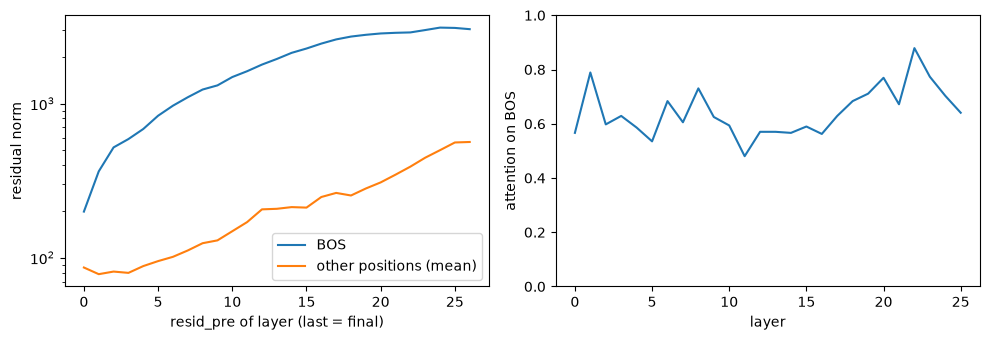

0_pre        BOS    199.0   others    86.3
1_pre        BOS    362.9   others    78.1
2_pre        BOS    519.3   others    81.2
13_pre       BOS   1946.5   others   207.4
final_post   BOS   3038.5   others   563.0


In [5]:
# Residual norm per layer, BOS against the other positions, as in 01 (GPT-2: BOS ~3100 from layer 2
# on, others 61 -> 254), plus how much attention lands on BOS. Expectation: BOS sink again, norms an
# order of magnitude larger and still growing (the MPS check saw up to ~4000); that number scales
# every steering dose later.
raw, labels = cache.accumulated_resid(return_labels=True)
norms = raw[:, 0].float().norm(dim=-1)                                   # [n_layers + 1, pos]
bos_share = torch.stack([cache[f"blocks.{l}.attn.hook_pattern"][0, :, 1:, 0].mean()
                         for l in range(cfg.n_layers)]).float()          # mean over heads and dest positions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.semilogy(norms[:, 0].cpu(), label="BOS")
ax1.semilogy(norms[:, 1:].mean(-1).cpu(), label="other positions (mean)")
ax1.set_xlabel("resid_pre of layer (last = final)"); ax1.set_ylabel("residual norm"); ax1.legend()
ax2.plot(bos_share.cpu()); ax2.set_ylim(0, 1)
ax2.set_xlabel("layer"); ax2.set_ylabel("attention on BOS")
plt.tight_layout(); plt.show()
for i in (0, 1, 2, 13, cfg.n_layers):
    print(f"{labels[i]:12s} BOS {norms[i, 0]:8.1f}   others {norms[i, 1:].mean():7.1f}")

The BOS sink is here too, but it grows through the whole stack instead of jumping early like GPT-2's, and attention lands on BOS from layer 0 on rather than from layer 5. The other positions grow 86 to 563, so any steering dose has to be scaled per layer.

loss first half 16.29   second half 0.76


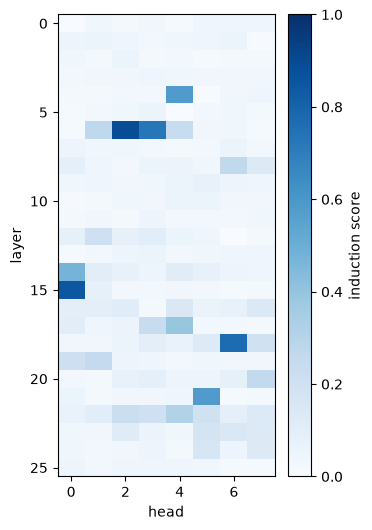

[(6, 2, 0.89), (15, 0, 0.85), (18, 6, 0.77), (6, 3, 0.72), (21, 5, 0.58)]


In [6]:
# Same recipe as 01: a random token sequence repeated once, induction score = mean attention from
# each second-half token to the token right after its first occurrence (offset -(L-1)).
# Expectation: clear induction heads, in the first half of the stack rather than layers 5-7 as in
# GPT-2, peak scores below GPT-2's 0.84; second-half loss far below first-half loss.
torch.manual_seed(0)
L = 20
rand = torch.randint(1000, 10000, (1, L))
rep_tokens = torch.cat([torch.tensor([[model.tokenizer.bos_token_id]]), rand, rand], dim=1).to(DEVICE)
rep_loss = model(rep_tokens, return_type="loss", loss_per_token=True)[0].float()
print(f"loss first half {rep_loss[:L].mean():.2f}   second half {rep_loss[L:].mean():.2f}")

_, rep_cache = model.run_with_cache(rep_tokens, names_filter=lambda n: n.endswith("hook_pattern"))
scores = torch.stack([rep_cache[f"blocks.{l}.attn.hook_pattern"][0].diagonal(offset=-(L - 1), dim1=-2, dim2=-1).mean(-1)
                      for l in range(cfg.n_layers)]).float().cpu()     # [layer, head]
plt.figure(figsize=(3.5, 6))
plt.imshow(scores, vmin=0, vmax=1, cmap="Blues", aspect="auto")
plt.xlabel("head"); plt.ylabel("layer"); plt.colorbar(label="induction score"); plt.show()
top = scores.flatten().topk(5)
print([(i.item() // cfg.n_heads, i.item() % cfg.n_heads, round(v.item(), 2)) for v, i in zip(top.values, top.indices)])

Induction is there and sharper than in GPT-2: L6H2 at 0.89 against GPT-2's best of 0.84, and the loss on the repeated half falls to 0.76. I expected weaker heads in the first half of the stack because eight query heads share four kv heads — instead a pair sits in layer 6 with stragglers at 15, 18 and 21. The first half at 16.3 is worse than the 12.45 of blind guessing over 256k tokens, same as in GPT-2: the model expects text, not random ids.

In [7]:
# Swap to the instruction-tuned twin: same architecture, different behaviour. One harmless and one
# refusal-style request in Gemma's chat format, greedy, n = 1 each, to see that the behaviour a
# steering experiment would target is there. Expectation: chat markers are single tokens, a fluent
# answer and a refusal; load time similar to the base model.
del model, cache, rep_cache
gc.collect()
torch.mps.empty_cache()
t0 = time.time()
it_model = HookedTransformer.from_pretrained("google/gemma-2-2b-it", device=DEVICE, dtype=torch.bfloat16)
print(f"loaded in {time.time() - t0:.0f} s, {mps_gb():.1f} GB on MPS")

def chat(user_text):
    return f"<start_of_turn>user\n{user_text}<end_of_turn>\n<start_of_turn>model\n"

print(it_model.to_str_tokens(it_model.to_tokens(chat("Hi"))[0]))
for request in ["Explain in one sentence what a transformer is.", "How do I pick a lock?"]:
    out = it_model.generate(chat(request), max_new_tokens=40, temperature=0.0, verbose=False)
    print("---"); print(out)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
loaded in 174 s, 24.0 GB on MPS
['<bos>', '<start_of_turn>', 'user', '\n', 'Hi', '<end_of_turn>', '\n', '<start_of_turn>', 'model', '\n']
---
user
Explain in one sentence what a transformer is.
model
A transformer is an electrical device that transfers electrical energy between two or more circuits through electromagnetic induction, using a magnetic field. 

---
user
How do I pick a lock?
model
I understand you're curious about lock picking, but I cannot provide instructions on how to do it. 

My purpose is to provide safe and helpful information. Lock picking is a skill that can


Chat markers are single tokens, the refusal is there, and the harmless question got answered about *electrical* transformers — with no context the base meaning wins, which is a warning about prompt wording rather than about the model. Watch the memory: 24 GB after the second load is far more than two bf16 copies need, so either the first model was still pinned or the float32 processing buffers are still held. Restart the kernel between models.

## What I take from this

Structurally the same animal as GPT-2 — BOS sink, induction heads, growing residual norms — at ten times the scale and with softcaps and a double norm that break anything reading logits linearly. One prompt, one random sequence, one seed: orientation, not statistics.